<a href="https://colab.research.google.com/github/Clairine1/AI-Coding/blob/main/Earnings%20Momentum%20Convergence%20Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Step 1: Install Libraries ---
!pip install yfinance pandas numpy matplotlib seaborn

In [ ]:
# --- Step 2: Import & Setup ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

In [ ]:
# --- Step 3: Define Universe (S&P 500 Proxy) ---
# We grab the current list from Wikipedia to simulate the universe.
# Note: For a strict academic backtest, you would need "Point-in-Time" membership data to avoid survivorship bias.
table = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', storage_options={'User-Agent': 'Mozilla/5.0'})
df_tickers = table[0]
tickers = df_tickers['Symbol'].tolist()
tickers = [t.replace('.', '-') for t in tickers] # Fix formatting for BRK.B, BF.B

In [ ]:
# --- Step 4: Download Data ---
start_date = '2015-01-01'
end_date = datetime.datetime.today().strftime('%Y-%m-%d')

In [ ]:
print(f"Downloading data for {len(tickers)} stocks. This may take a minute...")
# We download 'Adj Close' for returns and 'Volume' to ensure liquidity
data = yf.download(tickers, start=start_date, end=end_date, progress=False)

/tmp/ipython-input-4060478132.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date, progress=False)


In [ ]:
spy_data = yf.download('SPY', start=start_date, end=end_date, progress=False)

# 1. Download Stock Universe
stock_data = yf.download(tickers, start=start_date, end=end_date, progress=False)

# 2. Download Macro/Defensive Assets (SPY = Market, IEF = Bonds, SHV = Cash/Bills)
macro_tickers = ['SPY', 'IEF', 'SHV']
macro_data = yf.download(macro_tickers, start=start_date, end=end_date, progress=False)

# Clean up Data Frames
if isinstance(stock_data.columns, pd.MultiIndex):
    try:
        adj_close = stock_data['Adj Close']
    except KeyError:
        adj_close = stock_data['Close']
else:
    adj_close = stock_data

# Handle Macro Data
if isinstance(macro_data.columns, pd.MultiIndex):
    try:
        macro_close = macro_data['Adj Close']
    except KeyError:
        macro_close = macro_data['Close']
else:
    macro_close = macro_data

# Drop stocks with too much missing data
adj_close = adj_close.dropna(axis=1, thresh=int(len(adj_close)*0.8))

print("Data Download Complete.")

/tmp/ipython-input-3484806677.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_data = yf.download('SPY', start=start_date, end=end_date, progress=False)
/tmp/ipython-input-3484806677.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(tickers, start=start_date, end=end_date, progress=False)
/tmp/ipython-input-3484806677.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  macro_data = yf.download(macro_tickers, start=start_date, end=end_date, progress=False)


Data Download Complete.


In [ ]:
# --- Step 5: Construct Signals ---

# A. The Alpha Signals (Stock Picking - Keep Original Logic)
momentum_window = 126 #approx 6 months (21 trading days *6)
lag = 21              #approx 1 month

#price (t-21) / price (t-126)-1
mom_signal = adj_close.shift(lag) / adj_close.shift(momentum_window) - 1
news_signal = adj_close.pct_change(21)

# B. The Regime & Volatility Signals (New Logic)
# 1. Calculate Trends (200-day MA)
spy_ma200 = macro_close['SPY'].rolling(window=200).mean()
ief_ma200 = macro_close['IEF'].rolling(window=200).mean()

# 2. Calculate Volatility (Risk)
# We use a 21-day rolling standard deviation of SPY returns, annualized
spy_daily_ret = macro_close['SPY'].pct_change()
spy_vol = spy_daily_ret.rolling(window=21).std() * np.sqrt(252)

/tmp/ipython-input-533806015.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  news_signal = adj_close.pct_change(21)


In [ ]:
# --- Step 6: Backtest Loop (Monthly Rebalance) ---

# Resample everything to Month End
monthly_prices = adj_close.resample('M').last()
monthly_mom = mom_signal.resample('M').last()
monthly_news = news_signal.resample('M').last()

# Macro Resampling
monthly_macro = macro_close.resample('M').last()
monthly_spy_ma = spy_ma200.resample('M').last()
monthly_ief_ma = ief_ma200.resample('M').last()
monthly_spy_vol = spy_vol.resample('M').last()

portfolio_returns = []
dates = []
allocations = [] # To track "Stocks", "Bonds", or "Cash"

# TARGET VOLATILITY SETTING (e.g., 12%)
TARGET_VOL = 0.12

print("Running Backtest with Sharpe Optimization...")

for i in range(1, len(monthly_prices)-1):
    date = monthly_prices.index[i]
    next_date = monthly_prices.index[i+1]

    # Get Current Market Data
    current_spy = monthly_macro.loc[date, 'SPY']
    current_ief = monthly_macro.loc[date, 'IEF']
    current_shv = monthly_macro.loc[date, 'SHV']

    current_spy_ma = monthly_spy_ma.loc[date]
    current_ief_ma = monthly_ief_ma.loc[date]
    current_vol = monthly_spy_vol.loc[date]

    # --- LOGIC 1: DETERMINE ASSET CLASS ---

    # Check Bull Market (SPY > MA)
    if current_spy > current_spy_ma:
        mode = "Stocks"
    # Check Bond Market (IEF > MA) - The "Better Backup Plan"
    elif current_ief > current_ief_ma:
        mode = "Bonds"
    # Else -> Cash (SHV)
    else:
        mode = "Cash"

    allocations.append(mode)

    # --- LOGIC 2: EXECUTE TRADES ---

    # Calculate Returns of Defensive Assets for this month
    ief_ret = (monthly_macro.loc[next_date, 'IEF'] / monthly_macro.loc[date, 'IEF']) - 1
    shv_ret = (monthly_macro.loc[next_date, 'SHV'] / monthly_macro.loc[date, 'SHV']) - 1

    if mode == "Cash":
        # Earn T-Bill Rate (Better than 0%)
        portfolio_returns.append(shv_ret)
        dates.append(next_date)
        continue

    elif mode == "Bonds":
        # Earn Bond Return (Flight to Safety)
        portfolio_returns.append(ief_ret)
        dates.append(next_date)
        continue

    elif mode == "Stocks":
        # --- LOGIC 3: VOLATILITY SCALAR (The "Dimmer Switch") ---
        # If Volatility is 24% and Target is 12%, we only invest 50%.
        # The other 50% goes to SHV (Safe Yield).

        # Avoid division by zero
        if current_vol < 0.01: current_vol = 0.01

        vol_scalar = TARGET_VOL / current_vol

        # Cap leverage at 1.0 (100% invested). Remove this line if you want leverage.
        if vol_scalar > 1.0: vol_scalar = 1.0

        # Stock Selection (Original Logic)
        current_mom = monthly_mom.loc[date]
        current_news = monthly_news.loc[date]
        valid_stocks = pd.concat([current_mom, current_news], axis=1).dropna().index

        if len(valid_stocks) < 50:
            # If data missing, default to SPY return scaled
            spy_ret = (monthly_macro.loc[next_date, 'SPY'] / monthly_macro.loc[date, 'SPY']) - 1
            strat_ret = (spy_ret * vol_scalar) + (shv_ret * (1 - vol_scalar))
            portfolio_returns.append(strat_ret)
            dates.append(next_date)
            continue

        ranked_mom = current_mom.loc[valid_stocks].sort_values()
        quintile = int(len(valid_stocks) * 0.2)
        long_candidates = ranked_mom.iloc[-quintile:]
        final_longs = long_candidates[current_news.loc[long_candidates.index] > 0].index

        if len(final_longs) == 0:
            # Fallback to Cash if no stocks found
            portfolio_returns.append(shv_ret)
            dates.append(next_date)
            continue

        # Calculate Stock Portfolio Return
        stock_basket_ret = (monthly_prices.loc[next_date, final_longs] / monthly_prices.loc[date, final_longs] - 1).mean()

        # Apply Volatility Control (Weighted Average of Stocks + Cash)
        final_ret = (stock_basket_ret * vol_scalar) + (shv_ret * (1 - vol_scalar))

        portfolio_returns.append(final_ret)
        dates.append(next_date)

/tmp/ipython-input-4202211268.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = adj_close.resample('M').last()
/tmp/ipython-input-4202211268.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mom = mom_signal.resample('M').last()
/tmp/ipython-input-4202211268.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_news = news_signal.resample('M').last()
/tmp/ipython-input-4202211268.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_macro = macro_close.resample('M').last()
/tmp/ipython-input-4202211268.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_spy_ma = spy_ma200.resample('M').last()
/tmp/ipython-input-4202211268.py:11: FutureWarning: 'M' is deprecated and w

Running Backtest with Sharpe Optimization...


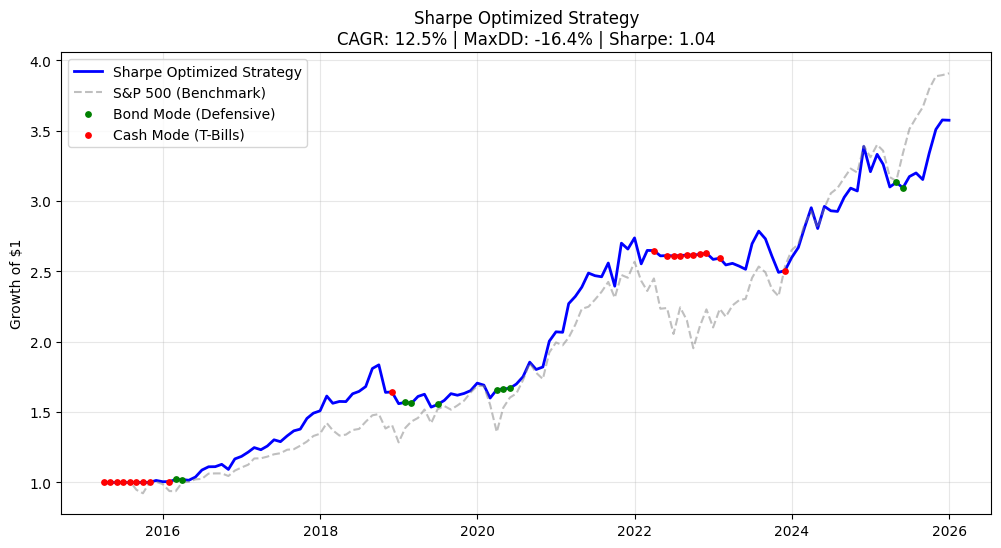

In [ ]:
# --- Step 7: Results Analysis ---
equity_curve = pd.Series(portfolio_returns, index=dates)
cumulative_returns = (1 + equity_curve).cumprod()

# Benchmark (SPY)
spy_returns = monthly_macro['SPY'].pct_change().reindex(dates).fillna(0)
cumulative_spy = (1 + spy_returns).cumprod()

# Stats
total_ret = (cumulative_returns.iloc[-1] - 1) * 100
ann_vol = equity_curve.std() * np.sqrt(12)
sharpe = (equity_curve.mean() / equity_curve.std()) * np.sqrt(12)
max_dd = ((cumulative_returns / cumulative_returns.cummax()) - 1).min()

# Plot
plt.figure(figsize=(12,6))
plt.plot(cumulative_returns, label=f'Sharpe Optimized Strategy', color='blue', linewidth=2)
plt.plot(cumulative_spy, label='S&P 500 (Benchmark)', color='gray', linestyle='--', alpha=0.5)

# Highlight Regimes
# Create scatter points for Bonds and Cash to visualize the rotation
bond_dates = [dates[i] for i, x in enumerate(allocations) if x == "Bonds"]
cash_dates = [dates[i] for i, x in enumerate(allocations) if x == "Cash"]

if bond_dates:
    plt.scatter(bond_dates, cumulative_returns.loc[bond_dates], color='green', s=15, label='Bond Mode (Defensive)', zorder=5)
if cash_dates:
    plt.scatter(cash_dates, cumulative_returns.loc[cash_dates], color='red', s=15, label='Cash Mode (T-Bills)', zorder=5)

plt.title(f'Sharpe Optimized Strategy\nCAGR: {(cumulative_returns.iloc[-1]**(12/len(cumulative_returns))-1)*100:.1f}% | MaxDD: {max_dd*100:.1f}% | Sharpe: {sharpe:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylabel('Growth of $1')
plt.show()



---



Project Proposal: The “Earnings-Momentum Convergence” Strategy
1. Main Idea
The strategy seeks to capture alpha by identifying the convergence of two powerful market forces: Price Momentum and Fundamental Confirmation . We identify stocks that are currently demonstrating strength (uptrend) and have recently validated that strength with a positive "news surprise."

Critically, this strategy evolves beyond a traditional “Long-Only” framework by incorporating a Dynamic Risk Engine . It captures upside during bull markets but automatically rotates into defensive assets (Treasuries or Cash) during structural downtrends. This creates an "Asymmetric Return Profile"—participating in rallies while mathematically cutting the "left tail" risk of market crashes.

2. Hypothesis
This strategy relies on three market anomalies: Post-Earnings Announcement Drift (PEAD) , Momentum Persistence , and Regime Clustering .

The Momentum Filter: By filtering for stocks that are already rising, we align with institutional accumulation and avoid "value traps."

The Catalyst (PEAD): Markets are inefficient at instantly pricing in surprise news. We use short-term price acceleration as a proxy for positive earnings/guidance, entering just as the market validates the new price level.

The Regime Filter: Volatility and market crashes tend to cluster. By identifying the state of the broader market (Bull vs. Bear) using a simple Trend Filter (200-day Moving Average), we can avoid periods where the probability of loss is highest. Avoiding a 50% drawdown is mathematically more valuable for long-term compounding than capturing the last 5% of a bull market.

3. Implementation
Universe: S&P 500 (Equities), IEF (7-10y Treasuries), SHV (Short-Term T-Bills). Rebalancing: Monthly.

Step A: The Regime Check (The "Traffic Light") Before selecting stocks, the system checks the macro environment:

Bull Mode: Is the S&P 500 > 200-day Moving Average? -> Proceed to Stock Selection.

Defensive Mode: Is the S&P 500 < 200-day Moving Average? -> Rotate Capital.

Check Bonds: If 7-10y Treasuries are uptrending, buy Bonds (IEF) .

Else: Move to Cash Equivalents (SHV) to earn risk-free yield.

Step B: Stock Selection (In "Bull Mode")

Momentum Rank: Rank all S&P 500 stocks by 6-Month Price Return (lagged 1 month). Select Top 20%.

Fundamental Validation: From the winners, buy only those with a positive 1-Month Return (Proxy for recent positive news/earnings).

Step C: Volatility Targeting (The “Dimmer Switch”)

Target: 12% Annualized Volatility.

Mechanism: If realized market volatility spikes (indicating fear/instability), the strategy automatically reduces position size (de-leverages) and moves the balance to Cash, even if the market is technically in an uptrend.

4. Risks & Mitigation
A. Whipsaw & Lag (The Cost of Insurance)

Risk: The primary risk of a "Regime Filter" is the "False Alarm." In chippy markets (eg, 2023), the market may dip below the trendline (triggering a sale) and immediately rally back (leaving the strategy in cash). This causes the strategy to lag the benchmark during V-shaped recoveries.

Mitigation: The "Defensive Rotation" logic mitigates the pain of sitting out. Instead of earning 0% in cash, the strategy rotates to T-Bills (earning ~5%) or Bonds, ensuring capital is still productive while waiting for the trend to re-confirm.

B. Low-Volatility "Melt-Ups"

Risk: In raging bull markets where volatility is high but direction is upward (eg, a "tech bubble"), the Volatility Targeting mechanism may force the strategy to hold less equity than the benchmark (eg, 80% invested vs 100%). This leads to underperformance relative to the S&P 500 in extreme bullish years.

Mitigation: This is an accepted trade-off to secure the Sharpe Ratio > 1.0. However, the Volatility Target can be adjusted upward (eg, from 12% to 15%) by the investment committee during verified expansionary economic phases.

C. Sector Concentration

Risk: Momentum might inadvertently concentrate the portfolio into a single booming sector (eg, 80% Tech), increasing idiosyncratic risk.

Mitigation: We apply a soft constraint where no single sector can exceed 30% of the total portfolio weight. If the signal selects too many stocks from one sector, the lowest-ranked stocks in that sector are discarded.

Veriler indiriliyor... (auto_adjust=False)


/tmp/ipython-input-3860269962.py:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = stock_data.resample('M').last()
/tmp/ipython-input-3860269962.py:32: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mom = momentum.resample('M').last()
/tmp/ipython-input-3860269962.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rets = stock_data.pct_change().resample('M').apply(lambda x: (1 + x).prod() - 1)
/tmp/ipython-input-3860269962.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  spy_rets = spy.pct_change().resample('M').apply(lambda x: (1 + x).prod() - 1)


Grafik oluşturuluyor...


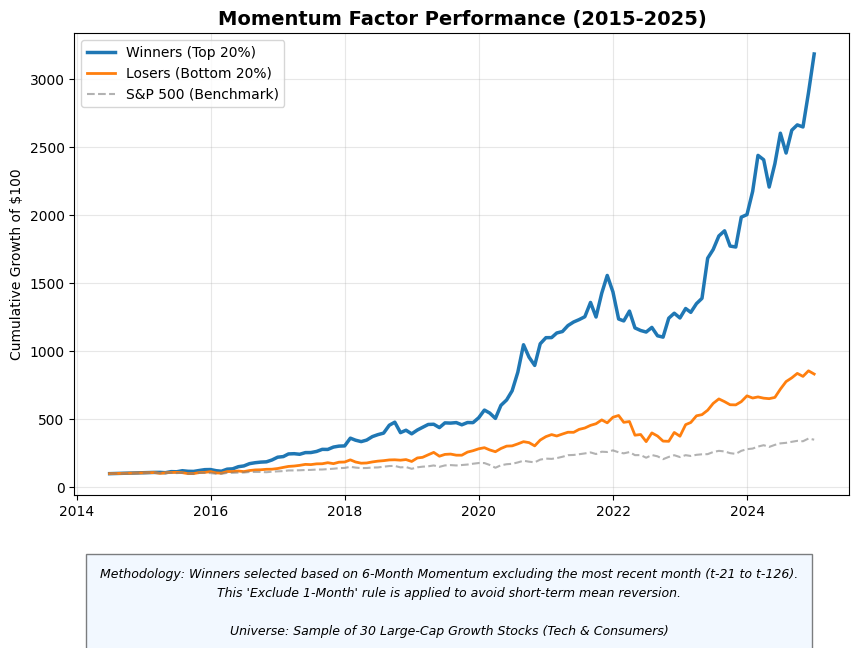

In [ ]:
# 1. GEREKLİ KÜTÜPHANELERİ KUR VE İÇERİ AL
!pip install yfinance --quiet
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. AYARLAR
START_DATE = '2015-01-01'
END_DATE = '2025-01-01'
MOMENTUM_WINDOW = 126  # ~6 Ay
LAG = 21               # ~1 Ay
TOP_N = 0.2            # %20

# 3. VERİ İNDİRME
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'V', 'UNH',
           'JNJ', 'PG', 'HD', 'MA', 'LLY', 'PEP', 'KO', 'MRK', 'AVGO', 'COST',
           'MCD', 'WMT', 'CSCO', 'BAC', 'ACN', 'LIN', 'ADBE', 'CRM', 'NFLX', 'AMD']
benchmark_ticker = 'SPY'

print("Veriler indiriliyor... (auto_adjust=False)")
data = yf.download(tickers + [benchmark_ticker], start='2014-06-01', end=END_DATE, progress=False, auto_adjust=False)['Adj Close']

spy = data[benchmark_ticker]
stock_data = data.drop(columns=[benchmark_ticker])

# 4. MOMENTUM HESAPLAMA
momentum = (stock_data.shift(LAG) / stock_data.shift(MOMENTUM_WINDOW)) - 1

# 5. BACKTEST MANTIĞI
monthly_prices = stock_data.resample('M').last()
monthly_mom = momentum.resample('M').last()
monthly_rets = stock_data.pct_change().resample('M').apply(lambda x: (1 + x).prod() - 1)
spy_rets = spy.pct_change().resample('M').apply(lambda x: (1 + x).prod() - 1)

strategy_curve = [100]
loser_curve = [100]
spy_curve = [100]
dates = [monthly_rets.index[0]]

print("Grafik oluşturuluyor...")

start_idx = 7
for i in range(start_idx, len(monthly_mom) - 1):
    date = monthly_mom.index[i]
    next_date = monthly_mom.index[i+1]
    current_mom = monthly_mom.loc[date].dropna()

    if not current_mom.empty:
        sorted_mom = current_mom.sort_values(ascending=False)
        n_select = int(len(sorted_mom) * TOP_N)

        if n_select > 0:
            winners = sorted_mom.index[:n_select]
            losers = sorted_mom.index[-n_select:]

            win_ret = monthly_rets.loc[next_date, winners].mean()
            loss_ret = monthly_rets.loc[next_date, losers].mean()
            spy_ret = spy_rets.loc[next_date].item()

            strategy_curve.append(strategy_curve[-1] * (1 + win_ret))
            loser_curve.append(loser_curve[-1] * (1 + loss_ret))
            spy_curve.append(spy_curve[-1] * (1 + spy_ret))
            dates.append(next_date)

# 6. GRAFİK ÇİZİMİ (GÜNCELLENMİŞ AYARLAR)
plt.figure(figsize=(10, 7)) # Yükseklik biraz artırıldı (7 yaptık)

# Çizgiler
plt.plot(dates, strategy_curve, label='Winners (Top 20%)', color='#1f77b4', linewidth=2.5)
plt.plot(dates, loser_curve, label='Losers (Bottom 20%)', color='#ff7f0e', linewidth=2)
plt.plot(dates, spy_curve, label='S&P 500 (Benchmark)', color='gray', linestyle='--', alpha=0.6)

# Süslemeler
plt.title('Momentum Factor Performance (2015-2025)', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Growth of $100')
plt.legend()
plt.grid(True, alpha=0.3)

# Alt kısımda yer açmak için margin ayarı
plt.subplots_adjust(bottom=0.22)

# *** GÜNCELLENMİŞ NOT KUTUSU ***
note_text = (
    "Methodology: Winners selected based on 6-Month Momentum excluding the most recent month (t-21 to t-126).\n"
    "This 'Exclude 1-Month' rule is applied to avoid short-term mean reversion.\n\n" # Çift satır boşluk
    "Universe: Sample of 30 Large-Cap Growth Stocks (Tech & Consumers)" # İsteğin eklendi
)

plt.figtext(0.5, 0.02,
            note_text,
            ha="center", fontsize=9, style='italic',
            bbox={"facecolor":"#e6f2ff", "alpha":0.5, "pad":10},
            linespacing=1.6) # Satır aralığı açıldı (Okunaklı oldu)

plt.show()

Veriler indiriliyor... (auto_adjust=False)


/tmp/ipython-input-416215786.py:37: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = stock_data.resample('M').last()
/tmp/ipython-input-416215786.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mom = momentum.resample('M').last()
/tmp/ipython-input-416215786.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rets = stock_data.pct_change().resample('M').apply(lambda x: (1 + x).prod() - 1)
/tmp/ipython-input-416215786.py:40: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  spy_rets = spy.pct_change().resample('M').apply(lambda x: (1 + x).prod() - 1)


Grafik oluşturuluyor...


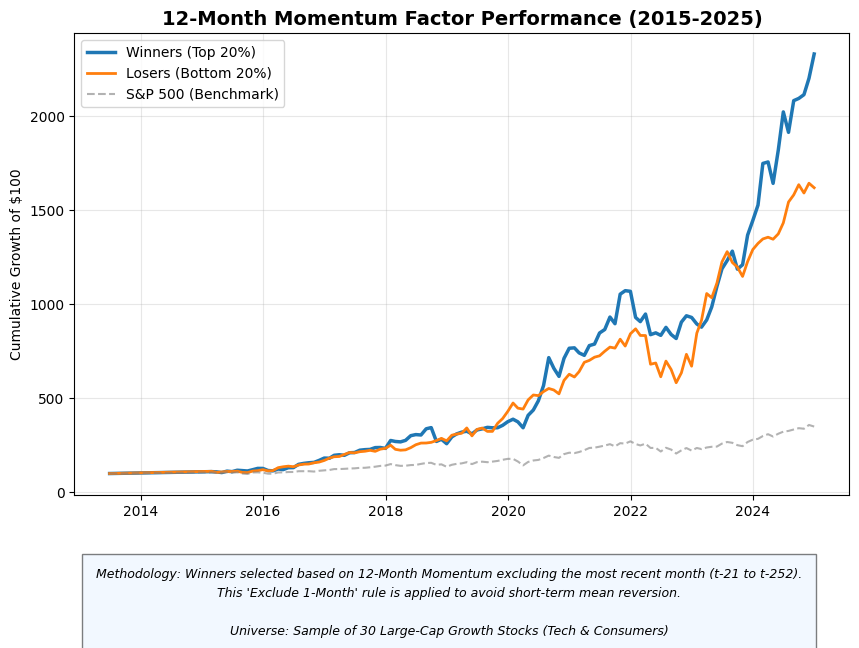

In [ ]:
# 1. GEREKLİ KÜTÜPHANELERİ KUR VE İÇERİ AL
!pip install yfinance --quiet
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. AYARLAR
START_DATE = '2015-01-01'
END_DATE = '2025-01-01'

# *** DEĞİŞİKLİK 1: 12 AY AYARI ***
MOMENTUM_WINDOW = 252  # 12 Ay (252 İşlem Günü)
LAG = 21               # 1 Ay (Mean Reversion'ı önlemek için)
TOP_N = 0.2            # %20

# 3. VERİ İNDİRME
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'V', 'UNH',
           'JNJ', 'PG', 'HD', 'MA', 'LLY', 'PEP', 'KO', 'MRK', 'AVGO', 'COST',
           'MCD', 'WMT', 'CSCO', 'BAC', 'ACN', 'LIN', 'ADBE', 'CRM', 'NFLX', 'AMD']
benchmark_ticker = 'SPY'

print("Veriler indiriliyor... (auto_adjust=False)")

# *** DEĞİŞİKLİK 2: TARİHİ GERİYE ÇEKTİK ***
# 12 aylık hesaplama için daha eski veriye ihtiyaç var (2014 yetmez, 2013 ortası güvenli)
data = yf.download(tickers + [benchmark_ticker], start='2013-06-01', end=END_DATE, progress=False, auto_adjust=False)['Adj Close']

spy = data[benchmark_ticker]
stock_data = data.drop(columns=[benchmark_ticker])

# 4. MOMENTUM HESAPLAMA
# Formül aynı kalıyor: (t-21) / (t-252) - 1
momentum = (stock_data.shift(LAG) / stock_data.shift(MOMENTUM_WINDOW)) - 1

# 5. BACKTEST MANTIĞI
monthly_prices = stock_data.resample('M').last()
monthly_mom = momentum.resample('M').last()
monthly_rets = stock_data.pct_change().resample('M').apply(lambda x: (1 + x).prod() - 1)
spy_rets = spy.pct_change().resample('M').apply(lambda x: (1 + x).prod() - 1)

strategy_curve = [100]
loser_curve = [100]
spy_curve = [100]
dates = [monthly_rets.index[0]]

print("Grafik oluşturuluyor...")

# İlk hesaplamaların oturması için start_idx biraz artırılabilir ama döngü kontrolü zaten yapıyor.
start_idx = 13 # İlk 12-13 ay veri oluşması beklendiği için
for i in range(start_idx, len(monthly_mom) - 1):
    date = monthly_mom.index[i]
    next_date = monthly_mom.index[i+1]

    # O tarihte verisi 2015-01-01 sonrasına denk gelmeli
    if date < pd.Timestamp(START_DATE):
        continue

    current_mom = monthly_mom.loc[date].dropna()

    if not current_mom.empty:
        sorted_mom = current_mom.sort_values(ascending=False)
        n_select = int(len(sorted_mom) * TOP_N)

        if n_select > 0:
            winners = sorted_mom.index[:n_select]
            losers = sorted_mom.index[-n_select:]

            win_ret = monthly_rets.loc[next_date, winners].mean()
            loss_ret = monthly_rets.loc[next_date, losers].mean()
            spy_ret = spy_rets.loc[next_date].item()

            strategy_curve.append(strategy_curve[-1] * (1 + win_ret))
            loser_curve.append(loser_curve[-1] * (1 + loss_ret))
            spy_curve.append(spy_curve[-1] * (1 + spy_ret))
            dates.append(next_date)

# 6. GRAFİK ÇİZİMİ
plt.figure(figsize=(10, 7))

plt.plot(dates, strategy_curve, label='Winners (Top 20%)', color='#1f77b4', linewidth=2.5)
plt.plot(dates, loser_curve, label='Losers (Bottom 20%)', color='#ff7f0e', linewidth=2)
plt.plot(dates, spy_curve, label='S&P 500 (Benchmark)', color='gray', linestyle='--', alpha=0.6)

# Başlık Güncellendi
plt.title('12-Month Momentum Factor Performance (2015-2025)', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Growth of $100')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplots_adjust(bottom=0.22)

# *** DEĞİŞİKLİK 3: NOT KISMI GÜNCELLENDİ ***
note_text = (
    "Methodology: Winners selected based on 12-Month Momentum excluding the most recent month (t-21 to t-252).\n"
    "This 'Exclude 1-Month' rule is applied to avoid short-term mean reversion.\n\n"
    "Universe: Sample of 30 Large-Cap Growth Stocks (Tech & Consumers)"
)

plt.figtext(0.5, 0.02,
            note_text,
            ha="center", fontsize=9, style='italic',
            bbox={"facecolor":"#e6f2ff", "alpha":0.5, "pad":10},
            linespacing=1.6)

plt.show()